In [1]:
for (pkg in c("ggplot2", "dplyr", "patchwork", "ggplotify")) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                pkg,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}

In [2]:
performances_file_path <- file.path("..", "results", "model_performances.parquet")
df <- arrow::read_parquet(performances_file_path)
df$feature <- gsub("all_terminal_features", "All features", df$feature)
df$feature <- gsub("Terminal_Cytoplasm_Intensity_UpperQuartileIntensity_AnnexinV", "AnnexinV\nsingle feature", df$feature)
df$shuffled <- gsub("shuffled", "Shuffled", df$shuffled)
df$shuffled <- gsub("not_Shuffled", "Not shuffled", df$shuffled)
df$shuffled <- factor(df$shuffled, levels = c("Not shuffled", "Shuffled"))


In [3]:
width <- 8
height <- 6
options(repr.plot.width = width, repr.plot.height = height)

In [4]:
df

model_name,data_split,shuffled,feature,mse,mae,r2
<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>
train_shuffled_elastic_net_single_terminal_features_model_shuffled.joblib,train,Shuffled,AnnexinV single feature,0.107233743,0.27336389,0.16974025
train_shuffled_elastic_net_single_terminal_features_model_shuffled.joblib,train,Shuffled,AnnexinV single feature,0.107233743,0.27336389,0.16974025
train_shuffled_elastic_net_single_terminal_features_model_shuffled.joblib,train,Shuffled,AnnexinV single feature,0.107233743,0.27336389,0.16974025
train_shuffled_elastic_net_single_terminal_features_model_shuffled.joblib,test,Shuffled,AnnexinV single feature,0.134867297,0.29619074,0.15015766
train_elastic_net_single_terminal_features_model.joblib,train,Not shuffled,AnnexinV single feature,0.007371329,0.07181236,0.94292732
train_elastic_net_single_terminal_features_model.joblib,test,Not shuffled,AnnexinV single feature,0.013047063,0.08267630,0.91778625
train_shuffled_elastic_net_all_annexinv_features_model_shuffled.joblib,train,Shuffled,All features,0.096929730,0.18650169,-0.02288804
train_shuffled_elastic_net_all_annexinv_features_model_shuffled.joblib,test,Shuffled,All features,0.098201603,0.19062295,-0.06617574
train_elastic_net_all_annexinv_features_model.joblib,train,Not shuffled,All features,0.011323054,0.07155026,0.54341362


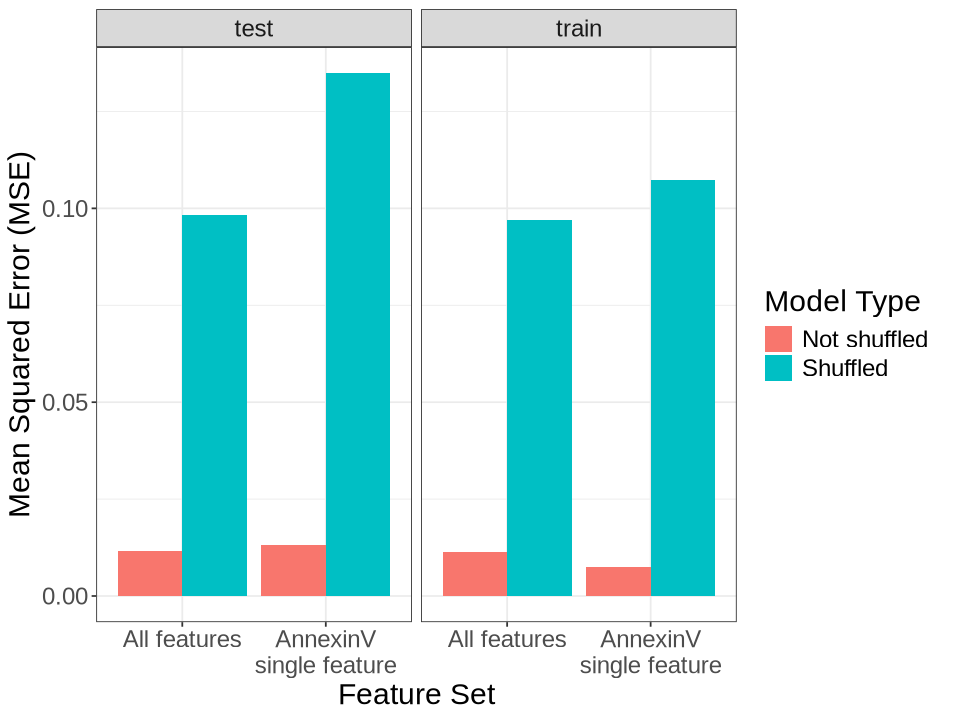

In [5]:
mse_plot <- (
    ggplot(df, aes(x = feature, y = mse, fill = shuffled))
    + geom_bar(stat = "identity", position = position_dodge()) 
    + theme_bw() 

    + labs(
        x = "Feature Set",
        y = "Mean Squared Error (MSE)"
    )
    + theme(text = element_text(size = 18))
    + guides(fill = guide_legend(title = "Model Type"))
    + facet_wrap(~data_split, nrow = 1, scales = "free_x")
)
mse_plot

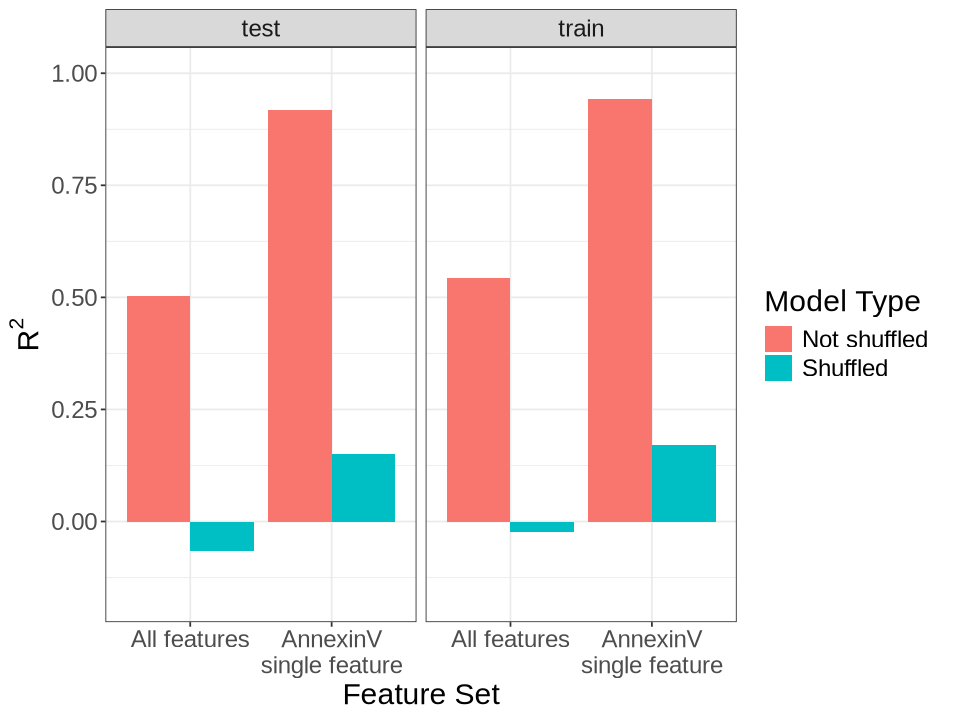

In [6]:
r2_plot <- (
    ggplot(df, aes(x = feature, y = r2, fill = shuffled))
    + geom_bar(stat = "identity", position = position_dodge()) 
    + theme_bw() 

    + labs(
        x = "Feature Set",
        y = expression(R^2)
    )
    + ylim(min(df$r2) - 0.1, 1)
    + theme(text = element_text(size = 18))
    + guides(fill = guide_legend(title = "Model Type"))
    + facet_wrap(~data_split, nrow = 1, scales = "free_x")


)
r2_plot

## Assemble final figure 

agg_record_1105720688 
                    2

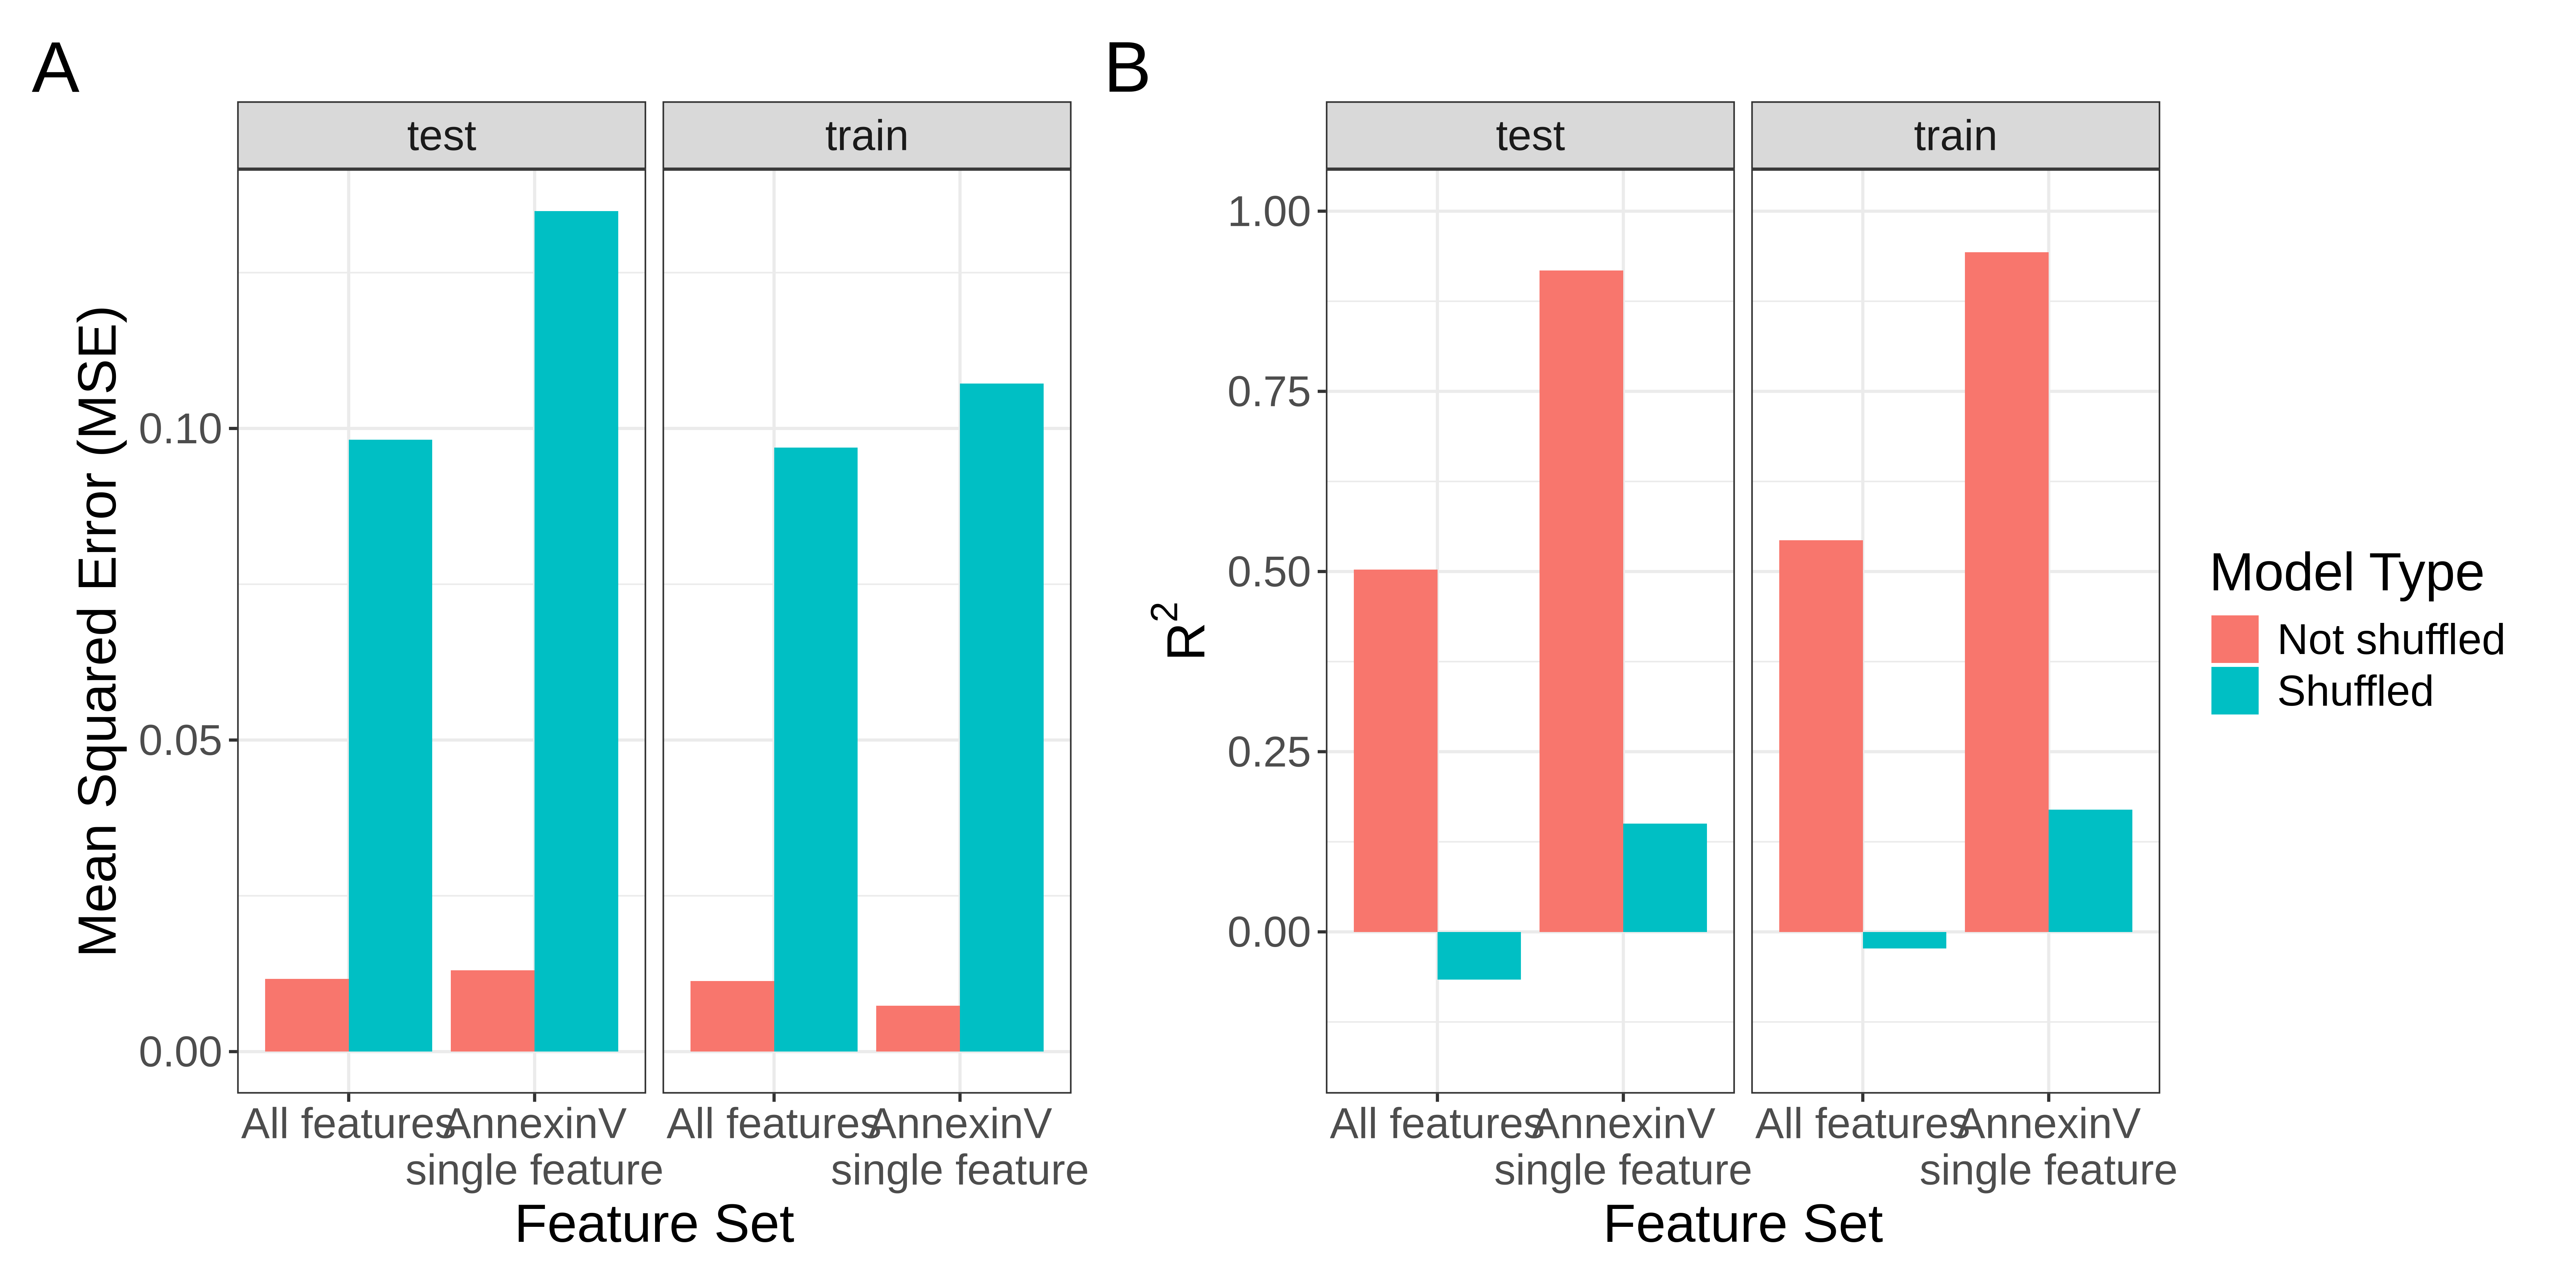

In [7]:
width <- 12
height <- 6
dpi <- 600
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = dpi)
final_plot <- (
    mse_plot
    + r2_plot
    + plot_layout(nrow = 1, guides = "collect")
    + plot_annotation(tag_levels = 'A') & theme(plot.tag = element_text(size = 24))
)
png(
    filename = file.path("..", "figures", "model_performances.png"),
    width = width,
    height = height,
    units = "in",
    res = dpi
)
final_plot
dev.off()
final_plot